importam tensorflow (pentru modelul cnn), matplotlib (pentru grafice)

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # opreste ceva mesaje de warning
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

from tensorflow.keras import datasets, layers, models
import helpers

ca sa aratam capabilitatile retelelor neuronale convolutionale (CNN), comparam cu o implementare naiva a unei retele FFNN (feed-forward).

din cauza ca reteaua FF nu intelege date sub forma de grid (2D) trebuie sa facem FLATTEN la datele de intrare din 32 (`width`) x 32 (`height`) x 3 (`canale`) intr-o singura lista 1D de 3072 de input-uri

/home/afra/utcn/anul3/si/cnn-demo/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


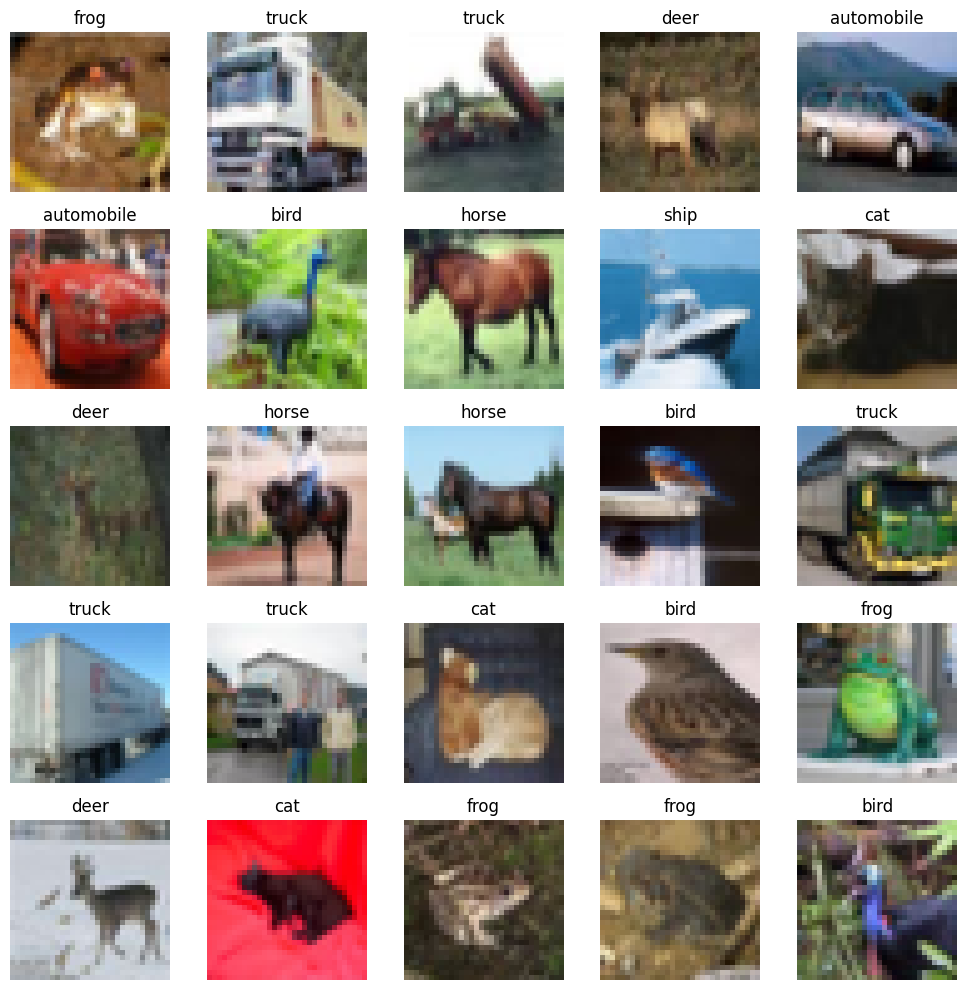

In [4]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

helpers.show_dataset(train_images, train_labels, class_names)


In [6]:
ffnn_model_simple = models.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),  # aplatizeaza imaginile
        layers.Dense(1024, activation="relu"),  # de ce??
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),  # softmax pentru clasificare
    ]
)

ffnn_model_simple.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"], jit_compile=False
)

ffnn_model_simple.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,676,682 (14.03 MB)

 Trainable params: 3,676,682 (14.03 MB)

 Non-trainable params: 0 (0.00 B)

observam numarul de parametrii, 3.6M reprezinta fiecare pixel din imagine conectat la fiecare alt pixel din imagine (crazy)

(atata matematica si tot nu o sa depaseasca 50% accuracy)

In [ ]:
history_ffnn_model = ffnn_model_simple.fit(
    train_images, train_labels, epochs=10, validation_data=(test_images, test_labels)
)

W0000 00:00:1777283106.516991   84650 cpu_allocator_impl.cc:82] Allocation of 614400000 exceeds 10% of free system memory.
W0000 00:00:1777283106.966479   84650 cpu_allocator_impl.cc:82] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/10


W0000 00:00:1777283108.265335   85200 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777283108.268746   85201 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777283108.271339   85202 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777283108.273915   85199 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777283108.276538   85197 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777283108.279357   85205 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1777283108.282637   85194 gpu_kernel_to_blob_pass.cc:190] Failed to co

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.3314 - loss: 1.8574 - val_accuracy: 0.3896 - val_loss: 1.6896
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4026 - loss: 1.6624 - val_accuracy: 0.4206 - val_loss: 1.6119
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4338 - loss: 1.5819 - val_accuracy: 0.4451 - val_loss: 1.5448
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4514 - loss: 1.5304 - val_accuracy: 0.4578 - val_loss: 1.5154
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4662 - loss: 1.4889 - val_accuracy: 0.4571 - val_loss: 1.5197
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4765 - loss: 1.4618 - val_accuracy: 0.4773 - val_loss: 1.4650
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4859 - loss: 1.4339 - val_accuracy: 0.4730 - val_loss: 1.4933
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4967 - loss: 1.4103 - v

ploturi

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


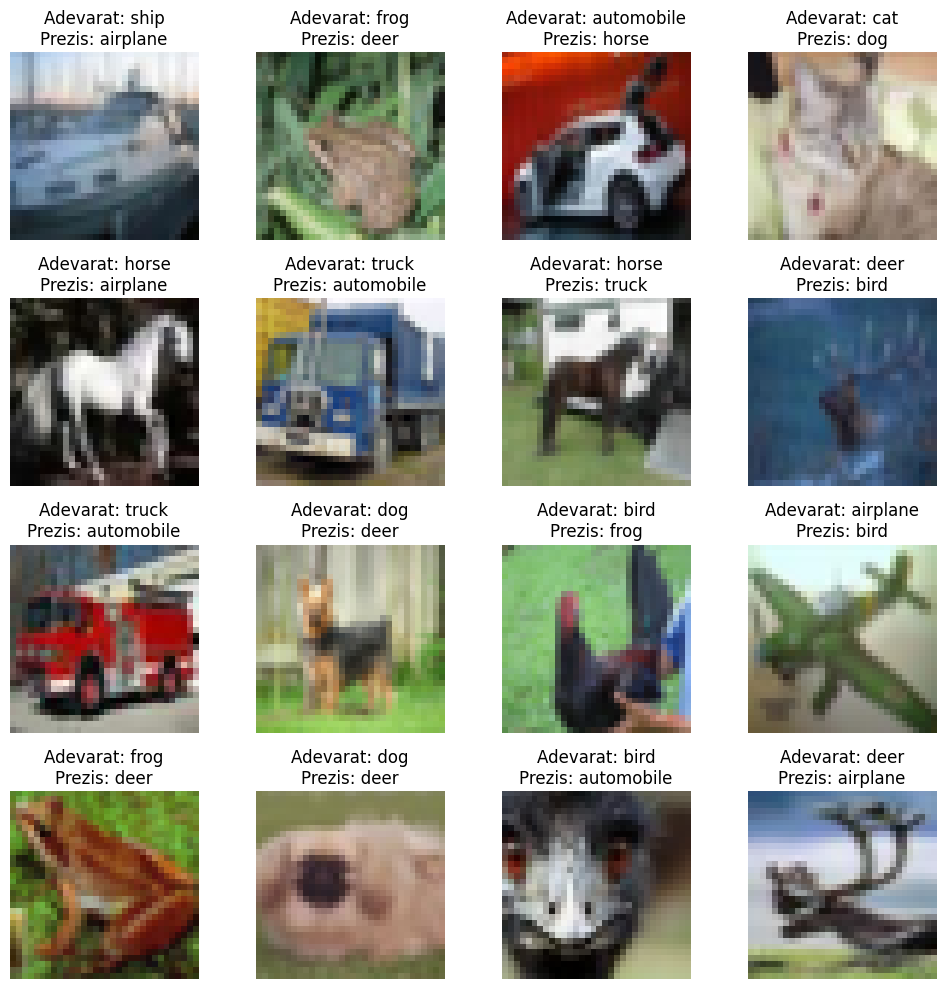

In [ ]:
helpers.plot_misclassification(ffnn_model_simple, test_images, test_labels, class_names, num_images=16)

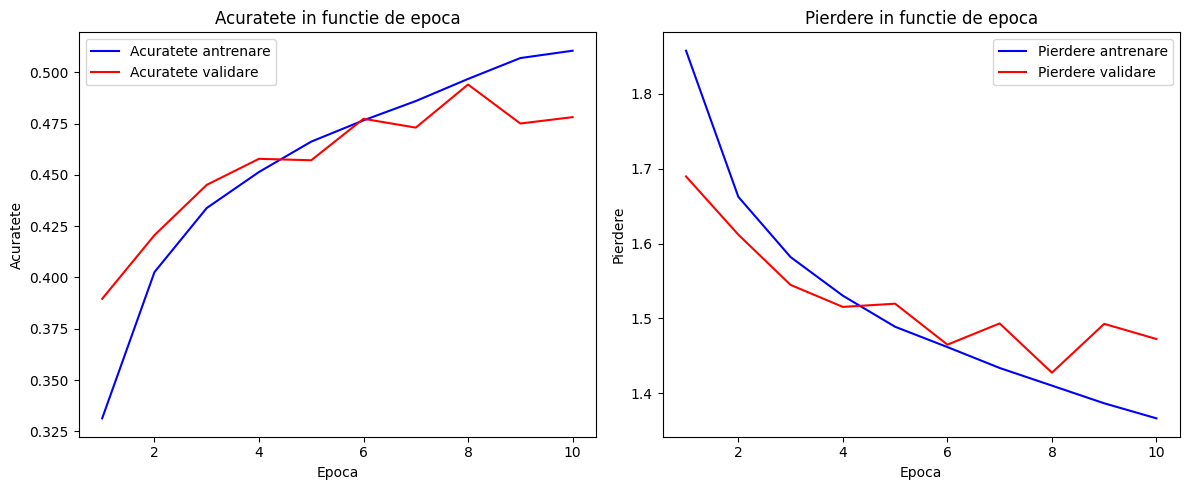

In [9]:
helpers.plot_learning_curve(history_ffnn_model)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

    airplane       0.51      0.57      0.54      1000
  automobile       0.57      0.63      0.60      1000
        bird       0.36      0.34      0.35      1000
         cat       0.42      0.22      0.29      1000
        deer       0.36      0.54      0.43      1000
         dog       0.41      0.38      0.39      1000
        frog       0.57      0.40      0.47      1000
       horse       0.52      0.58      0.55      1000
        ship       0.55      0.66      0.60      1000
       truck       0.52      0.47      0.49      1000

    accuracy                           0.48     10000
   macro avg       0.48      0.48      0.47     10000
weighted avg       0.48      0.48      0.47     10000



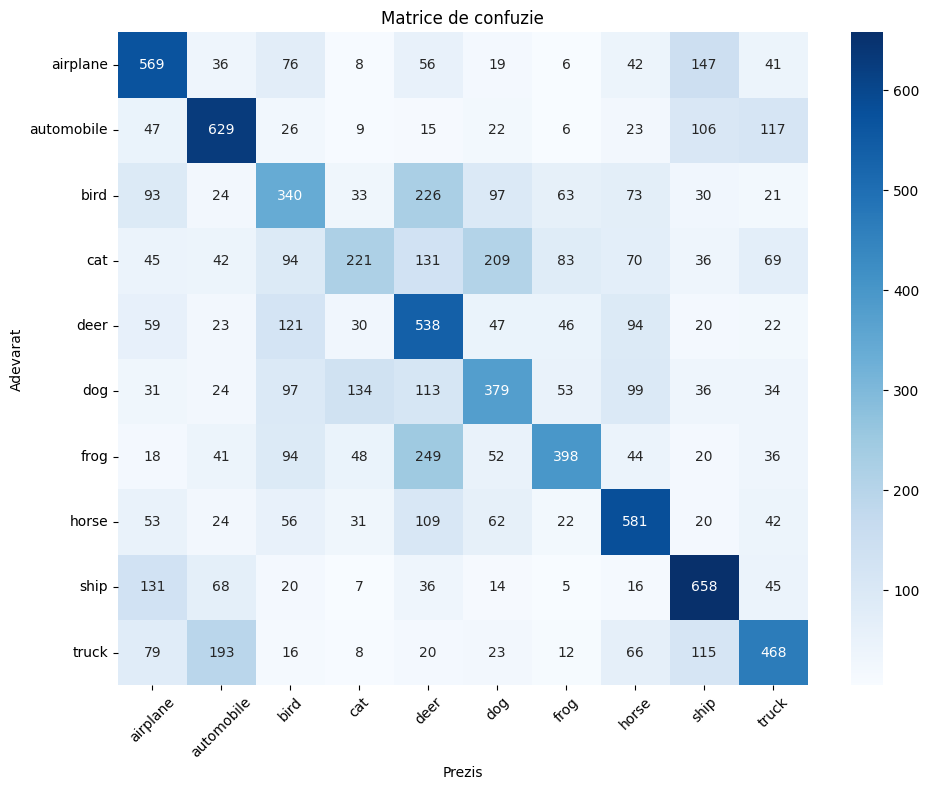

In [ ]:
helpers.plot_confusion_matrix(ffnn_model_simple, test_images, test_labels, class_names)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


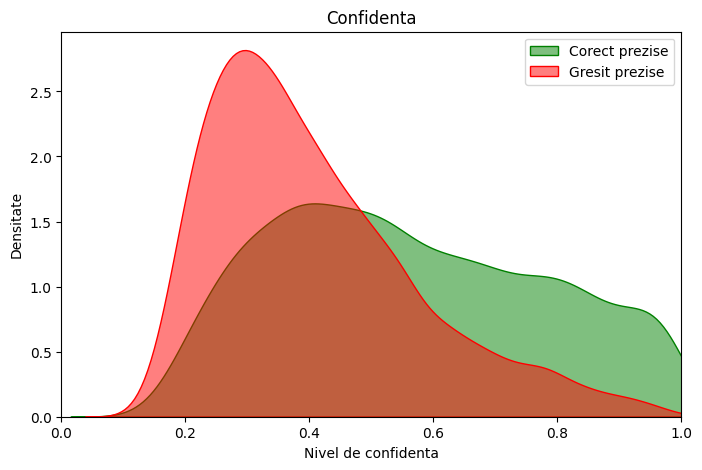

In [ ]:
helpers.plot_confidence_distribution(ffnn_model_simple, test_images, test_labels)